## 0. Constants/Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm
import glob

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import *
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import read_hdf

%load_ext autoreload
%autoreload 2

In [2]:
# Fill these
checkpoint = 'checkpoint7_full_contsig'
SMALL = False
VERSION = 'v8'
NCPU = 16
CONTAINED = True
CATEGORIES = [0] #Use this for xsec uncertainty and eff correction


PLOT_DIR = f'{DATA_DIR}/plots/{checkpoint}'
TABLE_DIR = f'{DATA_DIR}/tables/{checkpoint}'
SYST_DIR = f'{DATA_DIR}/data/{checkpoint}'

#MC Fnames
MC_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_syst/{VERSION}/*_fullsyst*/*.df'
)
DATA_OFFBEAM_FNAMES = glob.glob(
  f'{DATA_DIR}/offbeam/{VERSION}/*data*/*.df'
)
DATA_FNAMES = glob.glob(
  f'{DATA_DIR}/data/{VERSION}/*dataonbeam*/*.df'
)
MC_LOWE_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_lowe/{VERSION}/*_mclowe_*/*.df'
)

#Cuts
cuts_to_apply = PAND_CUTS_CONT.copy()
cuts_to_apply.pop(-2)

if SMALL:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//25]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//10]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//10]
else:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//9]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//5]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//5]

print('*' * 70)
print('checkpoint: ',checkpoint)
print('VERSION: ',VERSION)
print('NCPU: ',NCPU)
print('SMALL: ',SMALL)
print('CONTAINED: ',CONTAINED)
print('CATEGORIES: ',CATEGORIES)
print('cuts_to_apply: ',cuts_to_apply)
print('PLOT_DIR: ',PLOT_DIR)
print('TABLE_DIR: ',TABLE_DIR)
print('SYST_DIR: ',SYST_DIR)
print('*' * 70)

**********************************************************************
checkpoint:  checkpoint7_full_contsig
VERSION:  v8
NCPU:  16
SMALL:  False
CONTAINED:  True
CATEGORIES:  [0]
cuts_to_apply:  ['flashpe', 'flashmatch', 'cosmic', 'fv', 'muon', 'cont']
PLOT_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint7_full_contsig
TABLE_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/checkpoint7_full_contsig
SYST_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig
**********************************************************************


## 1. Load data

In [20]:
POT_LOWE = read_hdf(MC_LOWE_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_LOWE: {POT_LOWE:.2e}')
POT_MC = read_hdf(MC_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_MC: {POT_MC:.2e}')
LIVETIME_OFFBEAM = read_hdf(DATA_OFFBEAM_FNAMES,key=HDR_KEY, ncpu=NCPU, show_progress=True).noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')
POT_DATA = read_hdf(DATA_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_DATA = 9.51e5 # Temporary override
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
print(f'POT_LABEL: {POT_LABEL}')

read_hdf:   0%|          | 0/10 [00:00<?, ?it/s]

read_hdf: 100%|██████████| 10/10 [00:44<00:00,  4.44s/it]


LIVETIME_DATA: 9.51e+05
POT_LABEL: 5.95e+18 POT


In [4]:
# Get slices (apply cosmic cuts)
slc_mc_sel = CAFSlice.load(MC_FNAMES,
  key=PAND_SELECTED_KEY,
  ncpu=NCPU,
  preprocess=("flux",), #Combine flux weights
  show_progress=True
)
slc_mc_signal = CAFSlice.load(MC_FNAMES,
  key=PAND_SIGNAL_KEY,
  ncpu=NCPU,
  preprocess=("flux",), #Combine flux weights
  show_progress=True
)
if CATEGORIES == [0]:
  slc_mc_signal.cut_all(cut=True,mode='truth',cont=True) # Cut on signal.
slc_lowe = CAFSlice.load(MC_LOWE_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=False
)
slc_offbeam = CAFSlice.load(DATA_OFFBEAM_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=False
)
slc_data = CAFSlice.load(DATA_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=False
)

Loading combined CAF: 100%|██████████| 332/332 [00:36<00:00,  8.99it/s]


In [5]:
len([col for col in slc_mc_signal.data.columns if col[1] == "Flux_combine"])

100

### 1.1 Rescale to MC POT

In [6]:
# Rescale to POT_DATA
from sbnd.detector.definitions import F_SCALE
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True,f=F_SCALE)

slc_mc_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)

--scaling to POT (9.56e-02): 6.23e+19 -> 5.95e+18
--scaling to POT (2.27e-01): 2.63e+19 -> 5.95e+18
--scaling to livetime (2.55e-01): 3.46e+06 --> 9.51e+05
---scale factor without f: 2.7476e-01
--- f: 0.0725
--scaling to POT (9.56e-02): 6.23e+19 -> 5.95e+18


In [7]:
#Combine
# - selected
slc_mc_sel.combine(slc_offbeam,duplicate_ok=True,offset=int(2e6))
#del slc_offbeam
#Add statistical uncertainty before including lowe
slc_mc_sel.add_stat_unc(nuniv=100,progress_bar=True)
slc_mc_signal.add_stat_unc(nuniv=100,progress_bar=True) 
slc_mc_sel.combine(slc_lowe,duplicate_ok=True,offset=int(1e6))


Generating universes: 100%|██████████| 100/100 [02:22<00:00,  1.43s/it]


### 1.2 Assign binnings

In [17]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()

In [18]:
costheta_bins = COSTHETA_BINS
_costheta_bins = costheta_bins.copy()
_costheta_bins[-1] = 1.001 # Expand for last bin
momentum_bins = MOMENTUM_BINS
differential_edges = binning2d.differential_edges

In [10]:
#This should be empty
m1 = slc_mc_signal.data.true_bin.differential == -1
assert len(slc_mc_signal.data[m1]) == 0, f'{len(slc_mc_signal.data[m1])} slices have no differential bin'

In [11]:
#Smallest 5 bin counnts
slc_mc_signal.data.bin.differential.value_counts().iloc[-5:]

differential
33.0    560
32.0    537
27.0    534
31.0    122
30.0    100
Name: count, dtype: int64

### 1.3 Extract selected signal

In [12]:
class MaskedCAFData:
    """Row-masked view into a CAF dataframe (column access only, no full-frame copy)."""
    def __init__(self, data, mask):
        self._data = data
        self._mask = np.asarray(mask, dtype=bool)
    def keys(self):
        return self._data.keys()
    def __getitem__(self, col):
        return self._data.loc[self._mask, col]

sel_data = slc_mc_sel.data
is_signal = np.isin(sel_data.truth.event_type, CATEGORIES)
is_bkg = ~is_signal
mc_sel_signal_data = MaskedCAFData(sel_data, is_signal)
mc_sel_bkg_data = MaskedCAFData(sel_data, is_bkg)

### 1.4 Flux

In [13]:
# Extract flux from the flux file
import uproot
FLUX_FILE = "/exp/sbnd/data/users/munjung/xsec/flux_closure/Gen1FV_flux.root"
flux = uproot.open(FLUX_FILE)

# numu flux
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]

# get integrated flux
integrated_flux = flux_vals.sum()
integrated_flux /= 1e4 # to cm2
INTEGRATED_FLUX = np.float64(integrated_flux * POT_DATA / 1e6) # POT
print("Integrated flux: %.3e" % INTEGRATED_FLUX)

Integrated flux: 9.238e+10


In [14]:
NUMBER_TARGETS_FV

2.551404497074015e+31

In [15]:
#XSEC_UNIT = 1/ (INTEGRATED_FLUX * NTARGETS)
XSEC_UNIT = 1/ (INTEGRATED_FLUX * NUMBER_TARGETS_FV)
print(f'Xsec unit: {XSEC_UNIT}')

Xsec unit: 4.242545575082938e-43


### 1.5 Get binnings

In [16]:
#Signal
# -- reco
reco_sig_costheta = slc_mc_signal.data.mu.pfp.trk.costheta
reco_sig_momentum = slc_mc_signal.data.mu.pfp.trk.P.p_muon
reco_sig_differential = slc_mc_signal.data.bin.differential
# -- true
true_sig_costheta = slc_mc_signal.data.truth.mu.dir.z
true_sig_momentum = slc_mc_signal.data.truth.mu.totp
true_sig_differential = slc_mc_signal.data.true_bin.differential

#Selected signal (mask on sel_data, no full dataframe copy)
# -- reco
reco_sel_costheta = sel_data.mu.pfp.trk.costheta[is_signal]
reco_sel_momentum = sel_data.mu.pfp.trk.P.p_muon[is_signal]
reco_sel_differential = sel_data.bin.differential[is_signal]
# -- true
true_sel_costheta = sel_data.truth.mu.dir.z[is_signal]
true_sel_momentum = sel_data.truth.mu.totp[is_signal]
true_sel_differential = sel_data.true_bin.differential[is_signal]

# - Lowe only
# -- reco
reco_sel_lowe_costheta = slc_lowe.data.mu.pfp.trk.costheta
reco_sel_lowe_momentum = slc_lowe.data.mu.pfp.trk.P.p_muon
reco_sel_lowe_differential = slc_lowe.data.bin.differential
# -- true
true_sel_lowe_costheta = slc_lowe.data.truth.mu.dir.z
true_sel_lowe_momentum = slc_lowe.data.truth.mu.totp
true_sel_lowe_differential = slc_lowe.data.true_bin.differential

# Selected background
# -- reco
reco_sel_bkg_costheta = sel_data.mu.pfp.trk.costheta[is_bkg]
reco_sel_bkg_momentum = sel_data.mu.pfp.trk.P.p_muon[is_bkg]
reco_sel_bkg_differential = sel_data.bin.differential[is_bkg]
# -- true
true_sel_bkg_costheta = sel_data.truth.mu.dir.z[is_bkg]
true_sel_bkg_momentum = sel_data.truth.mu.totp[is_bkg]
true_sel_bkg_differential = sel_data.true_bin.differential[is_bkg]

# Data
data_costheta = slc_data.data.mu.pfp.trk.costheta
data_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_differential = slc_data.data.bin.costheta

# Weights
genweights_sig = slc_mc_signal.data.genweight
genweights_sel = sel_data.genweight[is_signal]
genweights_lowe = slc_lowe.data.genweight
genweights_sel_bkg = sel_data.genweight[is_bkg]
genweights_sel_signal = sel_data.genweight[is_signal]
genweights_data = slc_data.data.genweight

# Event-only variables (no true / xsec)
EVENT_VAR_SPECS = [
    ("bcfm", BCFM_BINS, "slc.barycenterFM.score"),
    ("flashpe", FLASHPE_BINS, "slc.barycenterFM.flashPEs"),
    ("startx", TRACK_XY_BINS, "mu.pfp.trk.start.x"),
    ("starty", TRACK_XY_BINS, "mu.pfp.trk.start.y"),
    ("startz", TRACK_Z_BINS, "mu.pfp.trk.start.z"),
    ("endx", TRACK_XY_BINS, "mu.pfp.trk.end.x"),
    ("endy", TRACK_XY_BINS, "mu.pfp.trk.end.y"),
    ("endz", TRACK_Z_BINS, "mu.pfp.trk.end.z"),
    ("phi", TRACK_PHI_BINS, "mu.pfp.trk.phi"),
    ("theta", TRACK_THETA_BINS, "mu.pfp.trk.theta"),
    ("length", TRACK_LENGTH_BINS, "mu.pfp.trk.len"),
    ("vtxx", TRACK_XY_BINS, "slc.vertex.x"),
    ("vtyy", TRACK_XY_BINS, "slc.vertex.y"),
    ("vtzx", TRACK_Z_BINS, "slc.vertex.z"),
]

def _event_col_values(slc, col_path, mask=None):
    col = slc.get_key(col_path)[0]
    vals = slc.data[col].values
    return vals[mask] if mask is not None else vals

event_reco_sel = {}
event_reco_bkg = {}
event_reco_lowe = {}
event_data = {}
event_bins = {}

for name, bins, col in EVENT_VAR_SPECS:
    event_bins[name] = bins
    event_reco_sel[name] = _event_col_values(slc_mc_sel, col, is_signal)
    event_reco_bkg[name] = _event_col_values(slc_mc_sel, col, is_bkg)
    event_reco_lowe[name] = _event_col_values(slc_lowe, col)
    event_data[name] = _event_col_values(slc_data, col)


In [17]:
np.sum(genweights_sel_signal)/np.sum(genweights_sig)

0.9009808435533604

### 1.7 (Optional) Test a dummy systematics

In [311]:
keys = ['truth.dumbysyst.univ_0','truth.dumbysyst.univ_1',
  'truth.GENIEdumbysyst.univ_0','truth.GENIEdumbysyst.univ_1']
for j, slc in enumerate([slc_mc_sel, slc_mc_signal]):
  vals = []
  for i in range(len(keys)):
    arr = np.ones(len(slc.data))
    #Artificially reduce efficiency
    if j == 1:
      arr *= 2.
    else:
      arr *= 0.5
    vals.append(arr)
  slc.add_cols(keys, vals)

## 2. Systematics

### 2.1. Create them

In [26]:
from sbnd.stats.systematics_old import Systematics
%load_ext autoreload
%autoreload 2
pattern = ['GENIE','Flux_combine','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2']
#del csystematics,msystematics,dsystematics
csystematics = Systematics('costheta', costheta_bins,
  reco_sel_costheta, reco_sel_bkg_costheta, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_costheta,
  true_sel=true_sel_costheta,
  true_sel_background=true_sel_bkg_costheta,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_costheta,
  genweights_data=genweights_data,
  pattern=pattern)
  #pattern=['dumbysyst'])

msystematics = Systematics('momentum', momentum_bins,
  reco_sel_momentum, reco_sel_bkg_momentum, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_momentum,
  true_sel=true_sel_momentum,
  true_sel_background=true_sel_bkg_momentum,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_momentum,
  genweights_data=genweights_data,
  pattern=pattern)
  #pattern=['dumbysyst'])

dsystematics = Systematics('differential', differential_edges,
  reco_sel_differential, reco_sel_bkg_differential, genweights_sig, genweights_sel, genweights_sel_bkg,
  xsec_unit=XSEC_UNIT,
  true_sig=true_sig_differential,
  true_sel=true_sel_differential,
  true_sel_background=true_sel_bkg_differential,
  keys=slc_mc_sel.data.truth.keys(),
  data=data_differential,
  genweights_data=genweights_data,
  pattern=pattern)
  #pattern=['dumbysyst'])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
csystematics_lowe = Systematics('costheta', costheta_bins,
  reco_sel_lowe_costheta, reco_sel_lowe_costheta, [], genweights_lowe, genweights_lowe,
  xsec_unit=XSEC_UNIT,
  true_sig=[],
  true_sel=true_sel_lowe_costheta,
  true_sel_background=true_sel_lowe_costheta,
  data=data_costheta,
  genweights_data=genweights_data)

msystematics_lowe = Systematics('momentum', momentum_bins,
  reco_sel_lowe_momentum, reco_sel_lowe_momentum, [], genweights_lowe, genweights_lowe,
  xsec_unit=XSEC_UNIT,
  true_sig=[],
  true_sel=true_sel_lowe_momentum,
  true_sel_background=true_sel_lowe_momentum,
  data=data_momentum,
  genweights_data=genweights_data)

dsystematics_lowe = Systematics('differential', differential_edges,
  reco_sel_lowe_differential, reco_sel_lowe_differential, [], genweights_lowe, genweights_lowe,
  xsec_unit=XSEC_UNIT,
  true_sig=[],
  true_sel=true_sel_lowe_differential,
  true_sel_background=true_sel_lowe_differential,
  data=data_differential,
  genweights_data=genweights_data)

event_systematics = []
event_systematics_lowe = []

for name, bins, col in EVENT_VAR_SPECS:
    s = Systematics(
        name, bins,
        event_reco_sel[name], event_reco_bkg[name],
        genweights_sig, genweights_sel, genweights_sel_bkg,
        keys=slc_mc_sel.data.truth.keys(),
        data=event_data[name],
        genweights_data=genweights_data,
        pattern=pattern,
    )
    s_lowe = Systematics(
        name, bins,
        event_reco_lowe[name], event_reco_lowe[name],
        [], genweights_lowe, genweights_lowe,
        data=event_data[name],
        genweights_data=genweights_data,
    )
    event_systematics.append(s)
    event_systematics_lowe.append(s_lowe)


In [28]:
# This should already be done
# for s in [slc_mc_sel_background,slc_mc_sel_signal,slc_mc_signal]:
#   s.add_stat_unc(nuniv=100,progress_bar=True)

In [29]:
for s,s_lowe in zip([csystematics,msystematics,dsystematics],[csystematics_lowe,msystematics_lowe,dsystematics_lowe]):
  s_lowe.process_stat_systematics(sys_key='stat_lowe')
  s.process_systematics(slc_mc_signal.data, mc_sel_signal_data, mc_sel_bkg_data, progress_bar=True)
  s.process_flat_systematic('pot',0.02)
  s.process_flat_systematic('nt',0.01)
  #s.process_stat_systematics(sys_key='stat_flat')
  s.compute_covariances()
  #break
  s_lowe.compute_covariances()
  try:
    s.combine(s_lowe,store_other=True,other_name='lowe',rescale_covs=False,rescale_fraccovs=True)
  except:
    print('Retrying...')
    try:
      s.combine(s_lowe,store_other=True,other_name='lowe',rescale_covs=False,rescale_fraccovs=True)
    except:
      raise Exception('Failed to combine systematics')
  s.combine_summaries(summary_keys=['total','flux','xsec','g4','stat'])

100%|██████████| 89/89 [01:20<00:00,  1.10 goomba/s]


 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_

100%|██████████| 89/89 [01:24<00:00,  1.06 goomba/s]


 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_

100%|██████████| 89/89 [00:58<00:00,  1.52 goomba/s]

 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:146: RuntimeWarning: invalid value encountered in divide
  return covariance / np.outer(cv, cv)


In [30]:

for s, s_lowe in zip(event_systematics, event_systematics_lowe):
    s_lowe.process_stat_systematics(sys_key='stat_lowe')
    s.process_systematics(slc_mc_signal.data, mc_sel_signal_data, mc_sel_bkg_data, progress_bar=True)
    s.process_flat_systematic('pot', 0.02)
    s.process_flat_systematic('nt', 0.01)
    s.compute_covariances(compute_xsec_cov=False)
    s_lowe.compute_covariances(compute_xsec_cov=False)
    try:
        s.combine(s_lowe, store_other=True, other_name='lowe', rescale_covs=False, rescale_fraccovs=True)
    except Exception:
        print('Retrying...')
        s.combine(s_lowe, store_other=True, other_name='lowe', rescale_covs=False, rescale_fraccovs=True)
    s.combine_summaries(summary_keys=['total', 'flux', 'xsec', 'g4', 'stat'])


100%|██████████| 89/89 [00:40<00:00,  2.22 goomba/s]


 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_

100%|██████████| 89/89 [00:40<00:00,  2.19 goomba/s]
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:146: RuntimeWarning: invalid value encountered in divide
  return covariance / np.outer(cv, cv)


 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_

100%|██████████| 89/89 [00:40<00:00,  2.20 goomba/s]
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:146: RuntimeWarning: invalid value encountered in divide
  return covariance / np.outer(cv, cv)


...

100%|██████████| 89/89 [00:40<00:00,  2.20 goomba/s]
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:146: RuntimeWarning: invalid value encountered in divide
  return covariance / np.outer(cv, cv)


 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_

100%|██████████| 89/89 [00:40<00:00,  2.21 goomba/s]

 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:146: RuntimeWarning: invalid value encountered in divide
  return covariance / np.outer(cv, cv)


In [31]:
print(msystematics.systematics['Flux_combine']['event_totalunc'])

0.06066102543427507


0.07229489508977062

In [32]:
csystematics.systematics['stat']['event_totalunc']

0.010733992640045695

0.008602141299850612

0.008481961483864054

In [33]:
dsystematics.systematics['stat_rw']['event_totalunc'],dsystematics.systematics['stat_lowe']['event_totalunc']

(0.021585524207830845, 0.002852757462285547)

In [34]:
SYST_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig'

In [35]:
#Save the systematics
checkpoint = 'checkpoint7_full_contsig'
subfolder = 'cont_full_small' if SMALL else 'cont_full_full'
for s in [csystematics,msystematics,dsystematics]:
  s.save(save_dir=f'{DATA_DIR}/data/{checkpoint}/syst/{subfolder}')
for s in event_systematics:
  s.save(save_dir=f'{DATA_DIR}/data/{checkpoint}/syst/{subfolder}')


Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full


Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/cont_full_full
Saving 38 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/

#### 2.0.1. Test the dummy systematics

In [315]:
# Check the key type pair for the systematics
for key,sdict in csystematics.systematics.items():
  print(key,sdict['type'])

dumbysyst unknown
GENIEdumbysyst xsec


In [316]:
csystematics.response

array([[0.34169279, 0.02439024, 0.00185185, 0.00379507, 0.00332779,
        0.00680272, 0.00484848, 0.004561  , 0.00726392],
       [0.02507837, 0.34494774, 0.03518519, 0.01328273, 0.00499168,
        0.        , 0.00242424, 0.0022805 , 0.00605327],
       [0.        , 0.05226481, 0.3       , 0.09677419, 0.        ,
        0.00453515, 0.00606061, 0.004561  , 0.00121065],
       [0.0031348 , 0.02787456, 0.08888889, 0.40986717, 0.10482529,
        0.00680272, 0.00242424, 0.00342075, 0.00484262],
       [0.02194357, 0.0174216 , 0.00555556, 0.10246679, 0.50415973,
        0.10204082, 0.00848485, 0.00684151, 0.00363196],
       [0.03448276, 0.        , 0.00925926, 0.00189753, 0.1014975 ,
        0.51473923, 0.12727273, 0.00570125, 0.00968523],
       [0.01253918, 0.00174216, 0.00185185, 0.01328273, 0.00831947,
        0.08956916, 0.54787879, 0.11402509, 0.01210654],
       [0.01567398, 0.01916376, 0.01851852, 0.0056926 , 0.00499168,
        0.00226757, 0.08      , 0.5940707 , 0.10532688],


In [317]:
csystematics.systematics['GENIEdumbysyst']['sel'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [318]:
(csystematics.sel + csystematics.sel_background)

array([ 865.2338624 , 1189.1821277 , 1458.74472054, 1773.49613742,
       2194.47804092, 2790.37069794, 2810.10897283, 3017.34837247,
       2848.11670274])

In [319]:
csystematics.sel_background/csystematics.systematics['GENIEdumbysyst']['sel_background'][0]

array([2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [320]:
csystematics.sel/(csystematics.systematics['GENIEdumbysyst']['sel'][0] - csystematics.systematics['GENIEdumbysyst']['sel_background'][0])

array([2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [321]:
csystematics.systematics['GENIEdumbysyst']['sigma_tilde'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [322]:
csystematics.sigma_tilde

array([ 865.2338624 , 1189.1821277 , 1458.74472054, 1773.49613742,
       2194.47804092, 2790.37069794, 2810.10897283, 3017.34837247,
       2848.11670274])

In [323]:
csystematics.sigma_tilde - csystematics.systematics['GENIEdumbysyst']['sigma_tilde'][0]

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [324]:
np.diag(np.sqrt(csystematics.systematics['GENIEdumbysyst']['xsec_cov']))

array([ 432.6169312 ,  594.59106385,  729.37236027,  886.74806871,
       1097.23902046, 1395.18534897, 1405.05448642, 1508.67418624,
       1424.05835137])

In [325]:
np.diag(np.sqrt(csystematics.systematics['dumbysyst']['xsec_cov']))

array([139.48670032, 111.32230483, 220.35567557, 175.70919786,
       140.60455077, 107.7890647 ,  99.83271513, 106.40254122,
        91.10804473])

In [326]:
csystematics.eff_truth

array([0.47962382, 0.49825784, 0.47962963, 0.65844402, 0.73710483,
       0.73015873, 0.78909091, 0.7958951 , 0.84745763])

In [327]:
csystematics.systematics['GENIEdumbysyst']['xsec_fracunc']

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [328]:
csystematics.systematics['dumbysyst']['xsec_fracunc']

array([0.16121272, 0.09361249, 0.15105842, 0.09907504, 0.06407198,
       0.03862894, 0.03552628, 0.03526359, 0.03198887])

In [329]:
csystematics.systematics['GENIEdumbysyst']['eff_truth'][0] - csystematics.eff_truth

array([-0.35971787, -0.37369338, -0.35972222, -0.49383302, -0.55282862,
       -0.54761905, -0.59181818, -0.59692132, -0.63559322])

In [330]:
csystematics.systematics['dumbysyst']['type'],csystematics.systematics['GENIEdumbysyst']['type']

('unknown', 'xsec')

In [332]:
msystematics.plot_all_distributions(plot_dir=f'{PLOT_DIR}/test')
msystematics.plot_all_distributions(plot_key='sigma_tilde',plot_dir=f'{PLOT_DIR}/test')

{'dumbysyst': {'sigma_tilde': [<Figure size 640x480 with 1 Axes>,
   <Axes: title={'center': 'dumbysyst sigma tilde momentum'}, xlabel='Reconstructed $p_{\\mu}$ (GeV)', ylabel='$\\tilde{\\sigma}$'>,
   None]},
 'GENIEdumbysyst': {'sigma_tilde': [<Figure size 640x480 with 1 Axes>,
   <Axes: title={'center': 'GENIEdumbysyst sigma tilde momentum'}, xlabel='Reconstructed $p_{\\mu}$ (GeV)', ylabel='$\\tilde{\\sigma}$'>,
   None]}}

#### 2.1.1. Merge full syst with det syst

In [37]:
DET_IGNORE_KEYS = [
    'total', 'xsec', 'nt', 'pot', 'geant4', 'geant4_syst', 'g4', 'flux',
    'stat_flat', 'stat', 'reinteractions', 'GENIE', 'Flux', 'cosmic_data',
    'metadata_detsys', 'metadata', 'detsys',
]
EVENT_ONLY_VAR_NAMES = [
    'bcfm', 'flashpe', 'startx', 'starty', 'startz', 'endx', 'endy', 'endz',
    'phi', 'theta', 'length', 'vtxx', 'vtyy', 'vtzx',
]
MERGE_VAR_NAMES = ['costheta', 'momentum', 'differential'] + EVENT_ONLY_VAR_NAMES

det_folder = f'{DATA_DIR}/data/checkpoint7_full/syst/cont'
det_systematics = {}
for var_name in MERGE_VAR_NAMES:
    det_systematics[var_name] = Systematics.from_saved(
        det_folder,
        var_name=var_name,
        metadata_dir='metadata_detsys',
        ignore_keys=DET_IGNORE_KEYS,
        lite=False,
        use_legacy_names=True,
        ncpus=NCPU,
    )

Loading systematics: 100%|██████████| 30/30 [00:37<00:00,  1.26s/ subfolder]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:34<00:00,  1.14s/ subfolder]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:37<00:00,  1.25s/ subfolder]


...

Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:17<00:00,  1.73 subfolder/s]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:17<00:00,  1.67 subfolder/s]

Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


In [38]:
rw_by_var = {
    'costheta': csystematics,
    'momentum': msystematics,
    'differential': dsystematics,
}
for s in event_systematics:
    rw_by_var[s.variable_name] = s

full_save_dir = f'{DATA_DIR}/data/{checkpoint}/syst/full'
for var_name in MERGE_VAR_NAMES:
    s = rw_by_var[var_name]
    s.combine(det_systematics[var_name], store_other=True, other_name='det_data')
    s.combine_summaries(summary_keys=['total'])
    s.save(save_dir=full_save_dir)

 -> [combine_summaries] Keys used in total: {'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_N', 'cosmic', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin3', 'alpha_embm1', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_1', 'R_embm1', 'nosce', 'GENIEReWeight_SBN_v1_multisigma_CV2uBY', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'beta_90m1', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_N', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi', 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_3', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_BhtBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi', 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_

### 2.2. Just load it

In [7]:
EVENT_ONLY_VAR_NAMES = [
    'bcfm', 'flashpe', 'startx', 'starty', 'startz', 'endx', 'endy', 'endz',
    'phi', 'theta', 'length', 'vtxx', 'vtyy', 'vtzx',
]
MERGE_VAR_NAMES = ['costheta', 'momentum', 'differential'] + EVENT_ONLY_VAR_NAMES
rw_by_var = {}

#### 2.2.1 Load and combine

In [ ]:
from sbnd.stats.systematics_old import Systematics
ncpus = NCPU
rw_folder = f'{DATA_DIR}/data/{checkpoint}/syst/cont_full_full'

for var_name in MERGE_VAR_NAMES:
    rw_by_var[var_name] = Systematics.from_saved(
        rw_folder, var_name=var_name, metadata_dir='metadata', ncpus=ncpus
    )

csystematics = rw_by_var['costheta']
msystematics = rw_by_var['momentum']
dsystematics = rw_by_var['differential']
event_systematics = [rw_by_var[name] for name in EVENT_ONLY_VAR_NAMES]

Loading systematics:   0%|          | 0/99 [00:00<?, ? subfolder/s]

Loading systematics:  17%|█▋        | 17/99 [00:23<01:51,  1.36s/ subfolder]


KeyboardInterrupt: 

In [ ]:
DET_IGNORE_KEYS = [
    'total', 'xsec', 'nt', 'pot', 'geant4', 'geant4_syst', 'g4', 'flux',
    'stat_flat', 'stat', 'reinteractions', 'GENIE', 'Flux', 'cosmic_data',
    'metadata_detsys', 'metadata', 'detsys',
]

det_folder = f'{DATA_DIR}/data/{checkpoint}/syst/cont'
det_systematics = {}
for var_name in MERGE_VAR_NAMES:
    det_systematics[var_name] = Systematics.from_saved(
        det_folder,
        var_name=var_name,
        metadata_dir='metadata_detsys',
        ignore_keys=DET_IGNORE_KEYS,
        lite=False,
        use_legacy_names=True,
        ncpus=NCPU,
    )

Loading systematics:   0%|          | 0/30 [00:00<?, ? subfolder/s]

Loading systematics: 100%|██████████| 30/30 [00:00<00:00, 147.15 subfolder/s]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:00<00:00, 147.59 subfolder/s]


Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


Loading systematics: 100%|██████████| 30/30 [00:00<00:00, 95.68 subfolder/s] 

Loaded 20 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full/syst/cont


In [ ]:
rw_by_var = {
    'costheta': csystematics,
    'momentum': msystematics,
    'differential': dsystematics,
}
for s in event_systematics:
    rw_by_var[s.variable_name] = s

full_save_dir = f'{DATA_DIR}/data/{checkpoint}/syst/full'
for var_name in MERGE_VAR_NAMES:
    s = rw_by_var[var_name]
    s.combine(det_systematics[var_name], store_other=True, other_name='det_data')
    s.combine_summaries(summary_keys=['total'])
    #s.save(save_dir=full_save_dir)

 -> [combine_summaries] Keys used in total: {'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b2', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_5', 'GENIEReWeight_SBN_v1_multisigma_FrPiProd_pi', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_NormNCMEC', 'GENIEReWeight_SBN_v1_multisigma_CV1uBY', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpNC1pi', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpCC1pi', 'GENIEReWeight_SBN_v1_multisigma_MaNCRES', 'alpha_embp1', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC1pi', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_2', 'MECq0q3InterpWeighting_SuSAv2ToValenica_q0binned_MECResponse_q0bin0', 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin2', 'cosmic', 'GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_FrPiProd_pi', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvnCC2pi', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin1', 'beta_90p1', 'MECq0q3InterpWeighting_SuSAv2ToMartini_q0binned_MECResponse_q0bin0', 'MECq0q3InterpWeighting_SuSAv2ToValen

#### 2.2.2 Load already combined

In [29]:
full_save_dir = f'{DATA_DIR}/data/{checkpoint}/syst/full'
#for var_name in ['costheta','momentum','differential']: #Just load xsec variable systematics
for var_name in MERGE_VAR_NAMES:
    rw_by_var[var_name] = Systematics.from_saved(
        full_save_dir, var_name=var_name, metadata_dir='metadata', ncpus=ncpus
    )

csystematics = rw_by_var['costheta']
msystematics = rw_by_var['momentum']
dsystematics = rw_by_var['differential']
event_systematics = [rw_by_var[name] for name in EVENT_ONLY_VAR_NAMES]

Loading systematics: 100%|██████████| 121/121 [02:15<00:00,  1.12s/ subfolder]


Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [02:08<00:00,  1.06s/ subfolder]


Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [02:17<00:00,  1.13s/ subfolder]


...

Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [01:41<00:00,  1.19 subfolder/s]


Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [01:42<00:00,  1.18 subfolder/s]

Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


In [30]:
#[s.compute_inverse_covariances() for s in [csystematics,msystematics,dsystematics]]
for s in [csystematics,msystematics,dsystematics]:
  s.xlabel = s._get_default_xlabel()
for s in event_systematics:
  s.xlabel = s._get_default_xlabel()


## 3. Plots

In [31]:
[s.compute_inverse_covariances() for s in [csystematics,msystematics,dsystematics]]
[s.compute_inverse_covariances() for s in event_systematics]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

### 3.1. All plots

In [32]:
PLOT_DIR = f'{DATA_DIR}/plots/checkpoint7_full_contsig2/syst'
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint7_full_contsig2/syst'

In [33]:
print(f'PLOT_DIR: {PLOT_DIR}')
combine_keys = ['calo','sce','tpc','pds','xsec','flux','g4']
summary_keys = ['total','flux','xsec','g4','calo','sce','tpc','pds','cosmic','stat','nt','pot']
suffix = '_contcut'

#All plots
subfolder_plot = f'{PLOT_DIR}/full/fracunc'
subfolder_dist = f'{PLOT_DIR}/full/dist'
subfolder_cov = f'{PLOT_DIR}/full/twod'

PLOT_DIR: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint7_full_contsig2/syst


In [ ]:
#for s,var_name in zip([csystematics,msystematics,dsystematics],['costheta','momentum','differential']):
for s,var_name in zip([csystematics,msystematics,dsystematics],['costheta','momentum','differential']):
#for s,var_name in zip([dsystematics],['differential']):
  s.set_colors()
  for unc_type in ['event','xsec']:
    if var_name == 'differential':
      bins = differential_edges
    elif var_name == 'costheta':
      bins = costheta_bins
    elif var_name == 'momentum':
      bins = momentum_bins
    #print(f'unc_type: {unc_type}, var_name: {var_name}')
    for use_fracunc in [True,False]:
      label = 'errs' if use_fracunc else 'unc'
      #All systematics
      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
      plotters.add_label(ax,INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot)
      # if use_fracunc:
      #   plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot_paper)
      plt.close()

      fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
      plotters.add_label(ax,INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
      plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot)
      # if use_fracunc:
      #   plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot_paper)
      plt.close()

      if var_name == 'differential':
        # All systematics
        fig,axs,_ = s.plot_event_rate_errs_2d(binning2d,f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
        plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
        plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
        plotters.save_plot(f'differential_{unc_type}_{label}_full{suffix}_2d',fig=fig,folder_name=subfolder_plot)
        plt.close()

        # Summary systematics
        fig,axs,_ = s.plot_event_rate_errs_2d(binning2d,f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
        plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
        plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
        plotters.save_plot(f'differential_{unc_type}_{label}_summary{suffix}_2d',fig=fig,folder_name=subfolder_plot)
        plt.close()
      #break
    #break
    
  # 9.2 Plot universes
  figs = s.plot_all_distributions(plot_key='sel',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)
  figs = s.plot_all_distributions(plot_key='sigma_tilde',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)

  # Plot covariance matrices
  s.plot_all_covariance_matrices(plot_dir=subfolder_cov,save_plots=True,progress_bar=True,suffix=suffix)

 61%|██████    | 74/121 [06:03<04:18,  5.51s/ goomba]

In [ ]:
# Event-only variable plots
for s in tqdm(event_systematics,total=len(event_systematics)):
    var_name = s.variable_name
    s.set_colors()
    for use_fracunc in [True, False]:
        label = 'errs' if use_fracunc else 'unc'
        fig, ax, im = s.plot_event_rate_errs('event', exclude_keys=combine_keys, use_fracunc=use_fracunc, sort=True)
        plotters.add_label(ax, INTERNAL_LABEL, where=(0.01, 1.01), fontsize=8, color='gray')
        plotters.add_label(ax, POT_LABEL, where='toprightoutside', color='black', alpha=1., fontsize=12)
        plotters.save_plot(f'{var_name}_event_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot)
        plt.close()

        fig, ax, im = s.plot_event_rate_errs('event', include_keys=summary_keys, use_fracunc=use_fracunc, sort=True)
        plotters.add_label(ax, INTERNAL_LABEL, where=(0.01, 1.01), fontsize=8, color='gray')
        plotters.add_label(ax, POT_LABEL, where='toprightoutside', color='black', alpha=1., fontsize=12)
        plotters.save_plot(f'{var_name}_event_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot)
        plt.close()

    s.plot_all_distributions(plot_key='sel', plot_dir=subfolder_dist, save_plots=True, suffix=suffix)
    #s.plot_all_covariance_matrices(plot_dir=subfolder_cov, save_plots=True, progress_bar=True, suffix=suffix)

  0%|          | 0/14 [00:00<?, ?it/s]

 14%|█▍        | 2/14 [00:08<00:51,  4.31s/it]

### 3.2. Specific plots

In [ ]:
subfolder_plot = f'{PLOT_DIR}/full/fracunc'
exclude_keys = ['total','flux','xsec','g4','calo','sce','tpc','pds','cosmic','stat']
for unctype in ['event','xsec']:
  #Costheta
  figax = csystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
  plotters.save_plot(f'costheta_{unctype}_errs_full{suffix}_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()
  #Momentum
  figax = msystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
  plotters.save_plot(f'momentum_{unctype}_errs_full{suffix}_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()
  #Differential
  figax = dsystematics.plot_event_rate_errs(unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  fig,ax = figax[0],figax[1]
  plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
  plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
  plotters.save_plot(f'differential_{unctype}_errs_full{suffix}_10unc',fig=fig,folder_name=subfolder_plot)
  plt.close()
  #Differential 2d
  fig,axs,_ = dsystematics.plot_event_rate_errs_2d(binning2d,unctype,sort=True,exclude_keys=exclude_keys,max_uncs=10)
  plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
  plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
  plotters.save_plot(f'differential_{unctype}_errs_full{suffix}_10unc_2d',fig=fig,folder_name=subfolder_plot)
  plt.close()
  
  

In [ ]:
#Differential
figax = dsystematics.plot_event_rate_errs('event',sort=True,include_keys=exclude_keys)
fig,ax = figax[0],figax[1]
ax.set_ylim(-0.02,0.7)
plotters.save_plot(f'differential_event_errs_summary{suffix}',fig=fig,folder_name=subfolder_plot)
plt.close()

figax = dsystematics.plot_event_rate_errs('xsec',sort=True,include_keys=exclude_keys)
fig,ax = figax[0],figax[1]
ax.set_ylim(-0.02,0.3)
plotters.save_plot(f'differential_xsec_errs_summary{suffix}',fig=fig,folder_name=subfolder_plot)
plt.close()


In [ ]:
# Plot specific types
type_map = { # Name: [max uncs, types]
  'xsec': [10,['xsec']],
  'flux': [None,['flux']],
  'g4': [None,['g4']],
  'det': [None,['calo','sce','tpc','pds']]
}
for name,info in type_map.items():
  for unc_type in ['event','xsec']:
    for use_fracunc in [True,False]:
      max_uncstr = info[0] if info[0] is not None else 'all'
      label = 'errs' if use_fracunc else 'unc'

      #Costheta
      figax = csystematics.plot_event_rate_errs(unc_type,sort=True,exclude_variations=['summary'],max_uncs=info[0],include_types=info[1],use_fracunc=use_fracunc)
      fig,ax = figax[0],figax[1]
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
      plotters.save_plot(f'costheta_{name}_{unc_type}_{label}_summary{suffix}_{max_uncstr}',fig=fig,folder_name=subfolder_plot)
      plt.close()

      #Momentum
      figax = msystematics.plot_event_rate_errs(unc_type,sort=True,exclude_variations=['summary'],max_uncs=info[0],include_types=info[1],use_fracunc=use_fracunc)
      fig,ax = figax[0],figax[1]
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
      plotters.save_plot(f'momentum_{name}_{unc_type}_{label}_summary{suffix}_{max_uncstr}',fig=fig,folder_name=subfolder_plot)
      plt.close()
      
      #Differential
      figax = dsystematics.plot_event_rate_errs(unc_type,sort=True,exclude_variations=['summary'],max_uncs=info[0],include_types=info[1],use_fracunc=use_fracunc)
      fig,ax = figax[0],figax[1]
      plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
      plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=12)
      plotters.save_plot(f'differential_{name}_{unc_type}_{label}_summary{suffix}_{max_uncstr}',fig=fig,folder_name=subfolder_plot)
      plt.close()

      #Differential 2d
      fig,axs,_ = dsystematics.plot_event_rate_errs_2d(binning2d,unc_type,sort=True,exclude_variations=['summary'],max_uncs=info[0],include_types=info[1],use_fracunc=use_fracunc)
      plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
      plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
      plotters.save_plot(f'differential_{name}_{unc_type}_{label}_summary{suffix}_{max_uncstr}_2d',fig=fig,folder_name=subfolder_plot)
      plt.close()

## 4. Make description template

In [ ]:
TABLE_DIR = f'{DATA_DIR}/tables/{checkpoint}/syst'
TABLE_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/checkpoint7_full_contsig/syst'

In [28]:
msystematics.systematics['xsec']['event_totalunc']

0.28757136759538593

In [ ]:
0.28757136759538593

0.28757136759538593

In [ ]:
from sbnd.general import latex_formatter
desc_path = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/systematic_descriptions.json'
ctemp = csystematics.generate_description_template(descriptions_path=desc_path)
mtemp = msystematics.generate_description_template(descriptions_path=desc_path)
dtemp = dsystematics.generate_description_template(descriptions_path=desc_path)

temps_dict = {
  r'$\cos\theta_\mu$': ctemp,
  r'$p_\mu$': mtemp,
  r'$\cos\theta_\mu$, \ $p_\mu$':dtemp
}

desc_latex = latex_formatter.description_table(ctemp,save_dir=TABLE_DIR)
unc_latex = latex_formatter.uncertainty_table(temps_dict,include_unc='both',save_dir=TABLE_DIR)#,sort_by_unc=True)

LaTeX table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/checkpoint7_full_contsig/syst/systematics_descriptions.tex
LaTeX table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/checkpoint7_full_contsig/syst/systematics_uncertainties.tex


In [12]:
caption = """
Mapping from 2D Bin ID to $p_\mu$ and $\cos\theta_\mu$ bin with corresponding overall bin widths used in cross section calculation.
"""
from sbnd.cafclasses.binning import Binning2D
diff_momentum_bins_2d = DIFF_MOMENTUM_BINS_2D.copy()
for i,arr in enumerate(diff_momentum_bins_2d):
  diff_momentum_bins_2d[i][-1] = MAX_PMOM
binning2d = Binning2D(diff_momentum_bins_2d=diff_momentum_bins_2d)
blatex = binning2d.to_latex(caption=caption,save_dir=TABLE_DIR)

Binning table saved to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tables/checkpoint7_full_contsig/syst/binning2d.tex


## 5. Test Covariance matrices

### 5.1 Break into groups

In [26]:
#Create empty df for groups that don't get filled
empty_df = slc_mc_sel.data.head(0).copy()

# Break data into lists of objects
slcs_sel_signal = []
slcs_sel_background = []
slcs_signal = []
slcs_sel = []
#Get event type col
slc_event_type_col = slc_mc_sel.get_key('truth.event_type')

# Group data by event type once
slc_signal_groups = slc_mc_signal.data.groupby(slc_event_type_col)
slc_sel_signal_groups = sel_data.loc[is_signal].groupby(slc_event_type_col)
slc_sel_background_groups = sel_data.loc[is_bkg].groupby(slc_event_type_col)
slc_sel_groups = slc_mc_sel.data.groupby(slc_event_type_col)
names = []

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
  if key == -1: 
    print(f'Skipping key: {val[0]}')
    continue
  if key in slc_signal_groups.groups:
    _slc_signal =  CAFSlice(slc_signal_groups.get_group(key))
  else:
    _slc_signal = CAFSlice(empty_df)
  if key in slc_sel_signal_groups.groups:
    _slc_sel_signal = CAFSlice(slc_sel_signal_groups.get_group(key))
  else:
    _slc_sel_signal = CAFSlice(empty_df)
  if key in slc_sel_background_groups.groups:
    _slc_sel_background = CAFSlice(slc_sel_background_groups.get_group(key))
  else:
    _slc_sel_background = CAFSlice(empty_df)
  if key in slc_sel_groups.groups:
    _slc_sel = CAFSlice(slc_sel_groups.get_group(key))
  else:
    _slc_sel = CAFSlice(empty_df)
  # Combine this with key 0, since they're both signal
  if key == 1:
    slcs_signal[0].combine(_slc_signal)
    slcs_sel_signal[0].combine(_slc_sel_signal)
    slcs_sel_background[0].combine(_slc_sel_background)
    slcs_sel[0].combine(_slc_sel)
    continue
  print(f'Appending {val[1]}')
  slcs_sel_signal.append(_slc_sel_signal)
  slcs_sel_background.append(_slc_sel_background)
  slcs_signal.append(_slc_signal)
  slcs_sel.append(_slc_sel)
  #Get name
  names.append(val[1])

Skipping key: Unknown


/tmp/ipykernel_110872/2733428164.py:25: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  _slc_signal =  CAFSlice(slc_signal_groups.get_group(key))
/tmp/ipykernel_110872/2733428164.py:29: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  _slc_sel_signal = CAFSlice(slc_sel_signal_groups.get_group(key))


/tmp/ipykernel_110872/2733428164.py:37: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  _slc_sel = CAFSlice(slc_sel_groups.get_group(key))


Appending numucc_cont


/tmp/ipykernel_110872/2733428164.py:33: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  _slc_sel_background = CAFSlice(slc_sel_background_groups.get_group(key))


Appending numucc_oops
Appending dirt
Appending nuecc
Appending nc
Appending cosmic


In [27]:
names = []
for k,val in EVENT_TYPE_LIST.items():
  if k in [-1,1]:
    continue
  names.append(val[1])

names[0] = names[0].split('_')[0]
names

['numucc', 'numucc_oops', 'dirt', 'nuecc', 'nc', 'cosmic']

In [28]:
#Signal
# -- reco
reco_sig_costheta_groups = [s.data.mu.pfp.trk.costheta for s in slcs_signal]
reco_sig_momentum_groups = [s.data.mu.pfp.trk.P.p_muon for s in slcs_signal]
reco_sig_differential_groups = [s.data.bin.differential for s in slcs_signal]
# -- true
true_sig_costheta_groups = [s.data.truth.mu.dir.z for s in slcs_signal]
true_sig_momentum_groups = [s.data.truth.mu.totp for s in slcs_signal]
true_sig_differential_groups = [s.data.true_bin.differential for s in slcs_signal]

#Selected signal
# -- reco
reco_sel_costheta_groups = [s.data.mu.pfp.trk.costheta for s in slcs_sel_signal]
reco_sel_momentum_groups = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sel_signal]
reco_sel_differential_groups = [s.data.bin.differential for s in slcs_sel_signal]
# -- true
true_sel_costheta_groups = [s.data.truth.mu.dir.z for s in slcs_sel_signal]
true_sel_momentum_groups = [s.data.truth.mu.totp for s in slcs_sel_signal]
true_sel_differential_groups = [s.data.true_bin.differential for s in slcs_sel_signal]

# Selected background
# -- reco
reco_sel_bkg_costheta_groups = [s.data.mu.pfp.trk.costheta for s in slcs_sel_background]
reco_sel_bkg_momentum_groups = [s.data.mu.pfp.trk.P.p_muon for s in slcs_sel_background]
reco_sel_bkg_differential_groups = [s.data.bin.differential for s in slcs_sel_background]
# -- true
true_sel_bkg_costheta_groups = [s.data.truth.mu.dir.z for s in slcs_sel_background]
true_sel_bkg_momentum_groups = [s.data.truth.mu.totp for s in slcs_sel_background]
true_sel_bkg_differential_groups = [s.data.true_bin.differential for s in slcs_sel_background]

# Weights
genweights_sig_groups = [s.data.genweight for s in slcs_signal]
genweights_sel_groups = [s.data.genweight for s in slcs_sel]
genweights_sel_bkg_groups = [s.data.genweight for s in slcs_sel_background]
genweights_sel_signal_groups = [s.data.genweight for s in slcs_sel_signal]

In [29]:
# Stats of each group
print(names)
print('Sig stats: ', [f'{g.sum():.1f}' for g in genweights_sig_groups])
print('Sel stats: ', [f'{g.sum():.1f}' for g in genweights_sel_groups])
print('Sel bkg stats: ', [f'{g.sum():.1f}' for g in genweights_sel_bkg_groups])
print('Sel signal stats: ', [f'{g.sum():.1f}' for g in genweights_sel_signal_groups])

['numucc', 'numucc_oops', 'dirt', 'nuecc', 'nc', 'cosmic']
Sig stats:  ['23328.9', '0.0', '0.0', '0.0', '0.0', '0.0']
Sel stats:  ['16362.7', '291.8', '523.9', '19.5', '497.5', '1217.4']
Sel bkg stats:  ['0.0', '291.8', '523.9', '19.5', '497.5', '1217.4']
Sel signal stats:  ['16362.7', '0.0', '0.0', '0.0', '0.0', '0.0']


### 5.2 Create systematic objects

In [ ]:
from sbnd.stats.systematics import Systematics
csystematic_systs, msystematic_systs, dsystematic_systs = [],[],[]

combine_keys = ['xsec','flux','g4']
suffix = '_lowzcut'
syst_keys = ['CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4','GENIEReWeight_SBN_v1_multisim_RPA_CCQE']
summary_keys = syst_keys

for i in tqdm(range(len(slcs_signal))):
    _csyst = Systematics('costheta', costheta_bins,
      reco_sel_costheta_groups[i], reco_sel_bkg_costheta_groups[i], genweights_sig_groups[0], genweights_sel_signal_groups[i], genweights_sel_bkg_groups[i],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_costheta_groups[0],
      true_sel=true_sel_costheta_groups[i],
      true_sel_background=true_sel_bkg_costheta_groups[i],
      keys=slc_mc_sel.data.truth.keys(),
      #data=data_costheta,
      #genweights_data=genweights_data,
      pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])

    _msyst = Systematics('momentum', momentum_bins,
      reco_sel_momentum_groups[i], reco_sel_bkg_momentum_groups[i], genweights_sig_groups[0], genweights_sel_signal_groups[i], genweights_sel_bkg_groups[i],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_momentum_groups[0],
      true_sel=true_sel_momentum_groups[i],
      true_sel_background=true_sel_bkg_momentum_groups[i],
      keys=slc_mc_sel.data.truth.keys(),
      #data=data_momentum,
      #genweights_data=genweights_data,
      pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])

    _dsyst = Systematics('differential', differential_edges,
      reco_sel_differential_groups[i], reco_sel_bkg_differential_groups[i], genweights_sig_groups[0], genweights_sel_signal_groups[i], genweights_sel_bkg_groups[i],
      xsec_unit=XSEC_UNIT,
      true_sig=true_sig_differential_groups[0],
      true_sel=true_sel_differential_groups[i],
      true_sel_background=true_sel_bkg_differential_groups[i],
      keys=slc_mc_sel.data.truth.keys(),
      #data=data_differential,
      #genweights_data=genweights_data,
      pattern=['GENIE','Flux','stat','reinteractions','SBNNuSyst','ZExp','SuSAv2'])

    for s in [_dsyst,_csyst,_msyst]:
      s.process_systematics(slcs_signal[i].data, slcs_sel_signal[i].data, slcs_sel_background[i].data, 
        sys_names=syst_keys,progress_bar=False)
      s.process_flat_systematic('pot',0.02)
      s.process_flat_systematic('nt',0.01)
      s.compute_covariances()
      s.combine_summaries(summary_keys=['total','flux','xsec','g4','stat'])
      #Save the systematics
      s.save(save_dir=f'{BASE_DIR}/data/{day}/syst/bg_studies/{names[i]}')

      #All plots
      subfolder_plot = f'{PLOT_DIR}/bg_studies/fracunc/{names[i]}'
      subfolder_dist = f'{PLOT_DIR}/bg_studies/dist/{names[i]}'
      subfolder_cov = f'{PLOT_DIR}/bg_studies/twod/{names[i]}'

      # Make plots
      var_name = s.variable_name
      for unc_type in ['event','xsec']:
        if var_name == 'differential':
          bins = differential_edges
        elif var_name == 'costheta':
          bins = costheta_bins
        elif var_name == 'momentum':
          bins = momentum_bins
        #print(f'unc_type: {unc_type}, var_name: {var_name}')
        for use_fracunc in [True,False]:
          label = 'errs' if use_fracunc else 'unc'
          #All systematics
          # fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
          # plotters.add_label(ax,INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
          # plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
          # plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot)
          # # if use_fracunc:
          # #   plotters.save_plot(f'{var_name}_{unc_type}_{label}_full{suffix}', fig=fig, folder_name=subfolder_plot_paper)
          # plt.close()

          fig,ax,im = s.plot_event_rate_errs(f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
          plotters.add_label(ax,INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
          plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
          plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot)
          # if use_fracunc:
          #   plotters.save_plot(f'{var_name}_{unc_type}_{label}_summary{suffix}', fig=fig, folder_name=subfolder_plot_paper)
          plt.close()

          if var_name == 'differential':
            # All systematics
            fig,axs,_ = s.plot_event_rate_errs_2d(binning2d,f'{unc_type}',exclude_keys=combine_keys,use_fracunc=use_fracunc,sort=True)
            plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
            plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
            plotters.save_plot(f'differential_{unc_type}_{label}_full{suffix}_2d',fig=fig,folder_name=subfolder_plot)
            plt.close()

            # Summary systematics
            fig,axs,_ = s.plot_event_rate_errs_2d(binning2d,f'{unc_type}',include_keys=summary_keys,use_fracunc=use_fracunc,sort=True)
            plotters.add_label(axs[0,0],INTERNAL_LABEL,where=(0.5, 1.09),fontsize=10,color='gray',horizontalalignment='left',verticalalignment='top')
            plotters.add_label(axs[0,2],POT_LABEL,where=(0.99, 1.09),color='gray',alpha=1.,fontsize=12,horizontalalignment='right',verticalalignment='top')
            plotters.save_plot(f'differential_{unc_type}_{label}_summary{suffix}_2d',fig=fig,folder_name=subfolder_plot)
            plt.close()
          #break
        #break
        
      # 9.2 Plot universes
      #figs = s.plot_all_distributions(plot_key='sel',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)
      #figs = s.plot_all_distributions(plot_key='sigma_tilde',plot_dir=subfolder_dist,save_plots=True,suffix=suffix)

      # Plot covariance matrices
      #s.plot_all_covariance_matrices(plot_dir=subfolder_cov,save_plots=True,progress_bar=True,suffix=suffix)

    #Store for the specific plots (if we need them)
    csystematic_systs.append(_csyst)
    msystematic_systs.append(_msyst)
    dsystematic_systs.append(_dsyst)

  0%|          | 0/6 [00:00<?, ?it/s]

Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc


Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc


 17%|█▋        | 1/6 [00:44<03:44, 44.93s/it]

Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc_oops
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc_oops
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/numucc_oops


...

 67%|██████▋   | 4/6 [02:12<01:02, 31.33s/it]

Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/nc
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/nc
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/nc


 83%|████████▎ | 5/6 [02:40<00:30, 30.02s/it]

Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/cosmic
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/cosmic
Saving 37 keys to /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4_limited/syst/bg_studies/cosmic


100%|██████████| 6/6 [03:07<00:00, 31.23s/it]


### 5.3 Find frac unc, scale to CV sigma tilde

In [190]:
# Get breakdown uncs
uncs = []
key_ind = 1
for i in range(len(dsystematic_systs)):
  fracunc = dsystematic_systs[i].systematics[syst_keys[key_ind]]['xsec_fracunc']
  unc = fracunc*dsystematic_systs[i].sigma_tilde
  uncs.append(unc)

# Get full sigma_tilde and fracunc
dsyst_full = Systematics.from_saved(f'{BASE_DIR}/data/checkpoint4/syst/full','differential',metadata_dir='metadata',select_keys=[syst_keys[key_ind]])
sigma_tilde = dsyst_full.sigma_tilde
fracunc = dsyst_full.systematics[syst_keys[key_ind]]['xsec_fracunc']

# Scale uncs to full sigma_tilde
fracuncs = [None]*len(uncs)
for i in range(len(uncs)):
  fracuncs[i] = uncs[i]/sigma_tilde

Loading systematics:   0%|          | 0/133 [00:00<?, ? subfolder/s]

Loading systematics: 100%|██████████| 133/133 [00:02<00:00, 59.28 subfolder/s]

Loaded 1 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/full


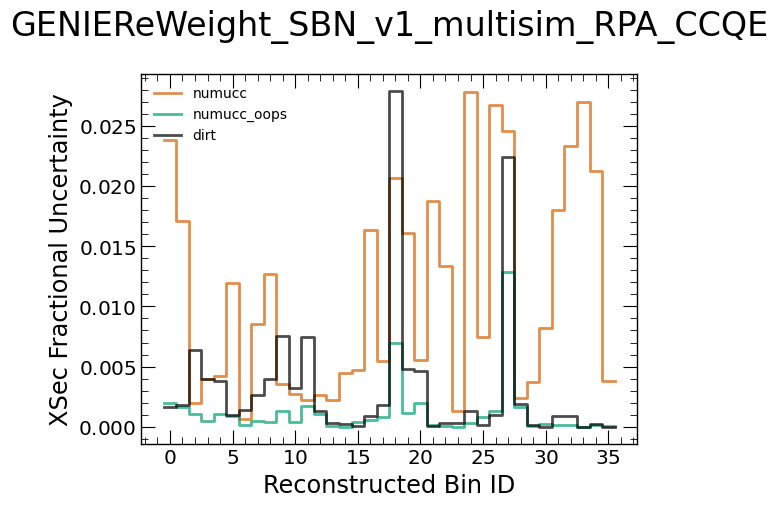

In [191]:
fig,ax = plt.subplots()
for i in range(len(fracuncs)):
  if names[i] == 'nuecc': break
  makeplot.plot_hist_edges(differential_edges,fracuncs[i],label=f'{names[i]}',alpha=0.7,ax=ax)
#makeplot.plot_hist_edges(differential_edges,fracunc,label=f'Full',alpha=1.0,color='red',ax=ax)
ax.legend()
ax.set_ylabel('XSec Fractional Uncertainty')
ax.set_xlabel('Reconstructed Bin ID')
ax.set_title(syst_keys[key_ind])
plt.show()

In [170]:
dsyst_full.systematics[syst_keys[key_ind]]['xsec_fracunc']

array([0.        , 0.02153775, 0.01317989, 0.01518804, 0.01042709,
       0.01058126, 0.00566454, 0.00372724, 0.01497626, 0.02599869,
       0.00412638, 0.0283931 , 0.01314428, 0.01122932, 0.01427127,
       0.0126209 , 0.01139684, 0.00624061, 0.00411381, 0.01770696,
       0.04936969, 0.03701295, 0.04649915, 0.03071604, 0.00991959,
       0.03882097, 0.00800297, 0.0098956 , 0.03447193, 0.01314107,
       0.01512252, 0.02779918, 0.05508334, 0.05688141, 0.06389103,
       0.03731233, 0.00540695])

### 5.4 Test Responses

In [82]:
responses = dsystematic_systs[0].systematics[syst_keys[0]]['response']
cv_response = dsystematic_systs[0].response
# Sigma_tildes
sigma_tildes = dsystematic_systs[0].systematics[syst_keys[0]]['sigma_tilde']
cv_sigma_tilde = dsystematic_systs[0].sigma_tilde

col_names = dsystematic_systs[0].systematics[syst_keys[0]]['col_names']
col_names = [c.split('_')[-1].replace('ps','+ sigma').replace('ms','- sigma') for c in col_names]
col_names


['+ sigma1', '- sigma1', '+ sigma2', '- sigma2', '+ sigma3', '- sigma3', 'cv']

In [126]:
col = slcs_sel[0].get_key(['bin.differential'])
base_key = 'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4'
cols = slcs_sel[0].get_key([f'{base_key}.ps1',f'{base_key}.ps2',f'{base_key}.ps3',f'{base_key}.ms1',f'{base_key}.ms2',f'{base_key}.ms3',f'{base_key}.cv'])
slcs_sel[0].data.loc[:,cols] = np.clip(slcs_sel[0].data.loc[:,cols],0,10)
weight_vals = slcs_sel[0].data.groupby(col).mean().loc[:,cols]

In [127]:
weight_vals.index

Index([ 0.0,  1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,  9.0, 10.0, 11.0,
       12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0,
       24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0],
      dtype='float64', name=('bin', 'differential', '', '', '', '', '', '', ''))

In [132]:
weight_vals

truth  \
                                  CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4   
                                                                                  ps1   
                                                                                        
                                                                                        
                                                                                        
                                                                                        
                                                                                        
                                                                                        
(bin, differential, , , , , , , )                                                       
0.0                                                                         0.959580    
1.0                                                                         0.945420    
2.0                                                                         0.985921    
3.0                                                                         0.983359    
4.0                                                                         0.988433    
5.0                                                                         0.988817    
6.0                                                                         0.991114    
7.0                                                                         0.992437    
8.0                                                                         0.998856    
9.0                                                                         0.877963    
10.0                                                                        0.834548    
11.0                                                                        0.931833    
12.0                                                                        0.881511    
13.0                                                                        0.953482    
14.0                                                                        0.992968    
15.0                                                                        0.979259    
16.0                                                                        1.005044    
17.0                                                                        1.007472    
18.0                                                                        0.748211    
19.0                                                                        0.724056    
20.0                                                                        0.791594    
21.0                                                                        0.749173    
22.0                                                                        0.829700    
23.0                                                                        0.935180    
24.0                                                                        0.892763    
25.0                                                                        0.984473    
26.0                                                                        1.003801    
27.0                                                                        0.861542    
28.0                                                                        0.811428    
29.0                                                                        0.753353    
30.0                                                                        0.766531    
31.0                                                                        0.764838    
32.0                                                                        0.826420    
33.0                                                                        0.854151    
34.0                                                                        0.920741    
35.0                                                                       

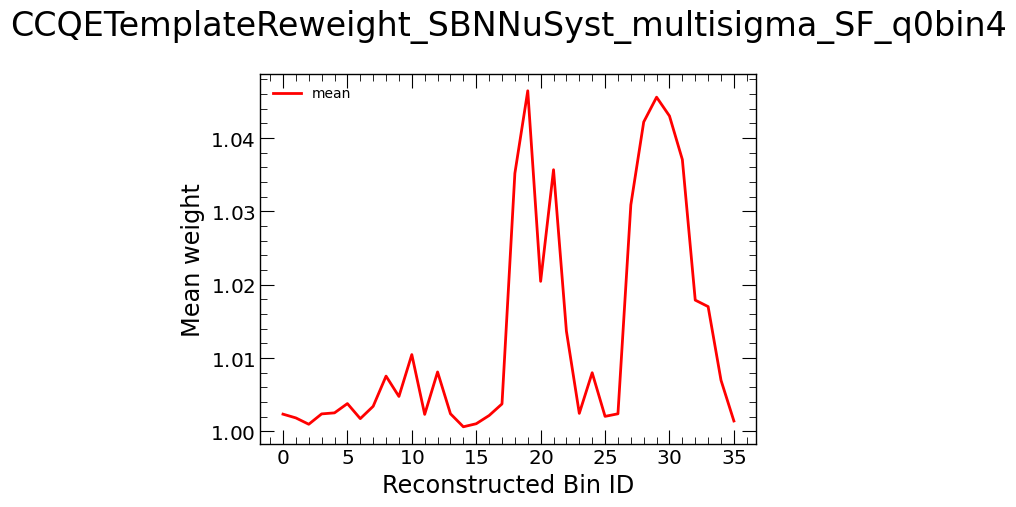

In [134]:
fig,ax = plt.subplots()
# for i in range(len(weight_vals.columns)):
#   ax.plot(weight_vals.index,weight_vals.values[:,i],label=f'{col_names[i]}',alpha=0.3)
ax.plot(weight_vals.index,np.mean(weight_vals.values[:,:-1],axis=1),label='mean',alpha=1.0,color='red')
ax.legend()
ax.set_xlabel('Reconstructed Bin ID')
ax.set_ylabel('Mean weight')
ax.set_title(syst_keys[0])
plt.show()

In [83]:
len(responses)

6

/tmp/ipykernel_110872/1732493484.py:3: RuntimeWarning: invalid value encountered in divide
  ratio = np.diag(responses[i])/np.diag(cv_response)
/tmp/ipykernel_110872/1732493484.py:5: RuntimeWarning: invalid value encountered in divide
  ratio = np.diag(np.mean(responses,axis=0))/np.diag(cv_response)


(0.9, 1.1)

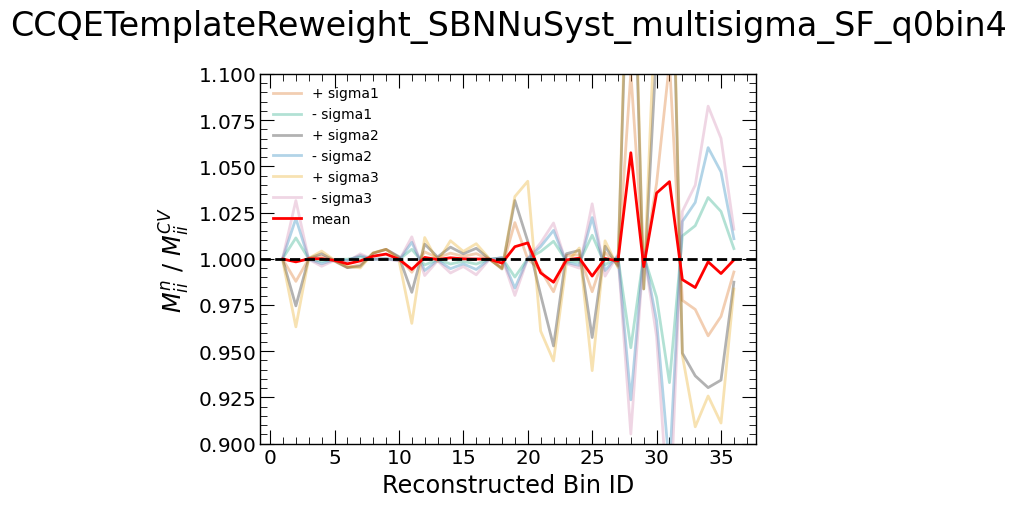

In [92]:
fig,ax = plt.subplots()
for i in range(len(responses)):
  ratio = np.diag(responses[i])/np.diag(cv_response)
  ax.plot(ratio,label=f'{col_names[i]}',alpha=0.3)
ratio = np.diag(np.mean(responses,axis=0))/np.diag(cv_response)
ax.plot(ratio,label='mean',alpha=1.0,color='red')
ax.axhline(1,color='black',linestyle='--')
ax.set_xlabel('Reconstructed Bin ID')
ax.set_ylabel(r'$M_{ii}^n \ / \ M_{ii}^{CV}$')
ax.set_title(syst_keys[0])
ax.legend()
ax.set_ylim(0.9,1.1)

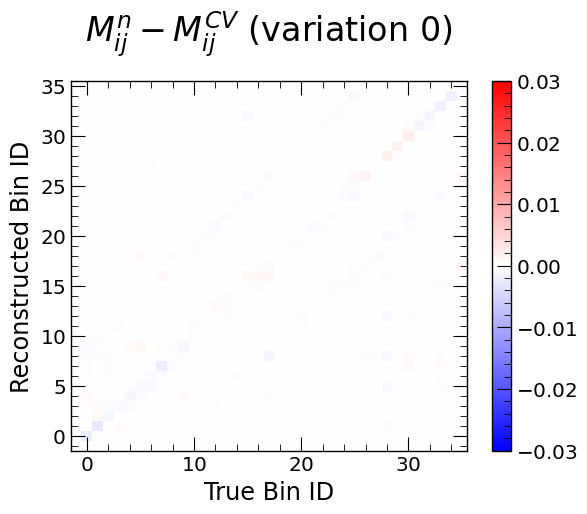

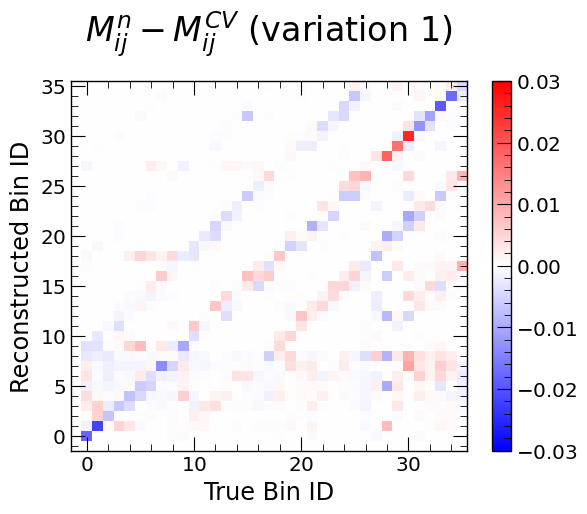

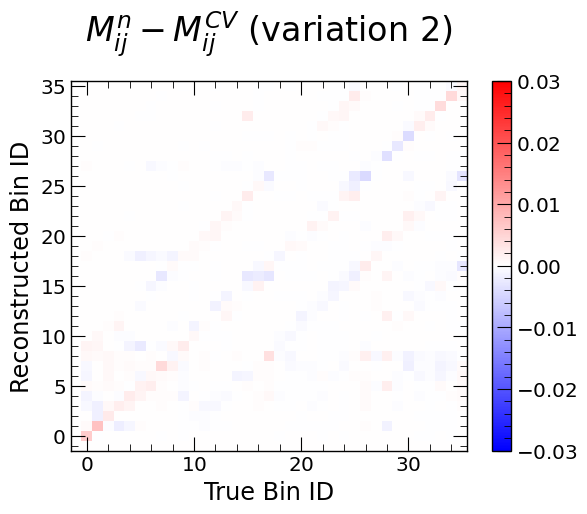

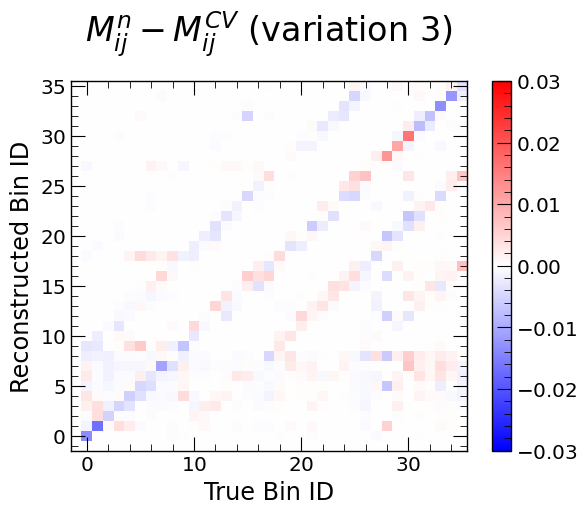

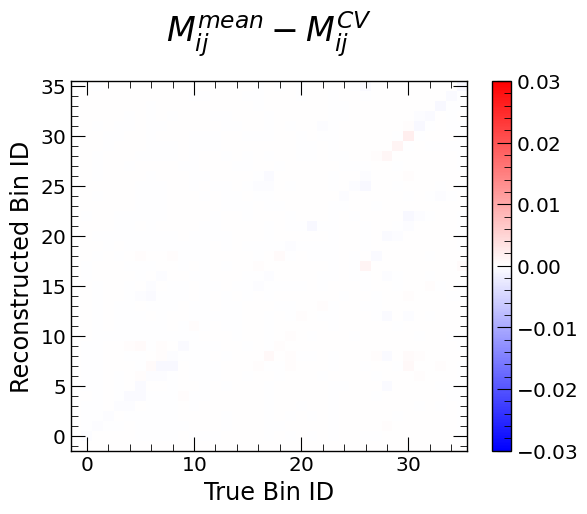

In [57]:
for variation in range(5):
  trigger = len(responses)
  trigger = 4
  fig,ax = plt.subplots()
  r = np.mean(responses,axis=0) if variation == trigger else responses[variation]
  im = ax.pcolormesh(binning2d.differential_edges,binning2d.differential_edges,
    r-cv_response,vmin=-0.03,vmax=0.03,cmap='bwr')
  fig.colorbar(im)
  ax.set_xlabel('True Bin ID')
  ax.set_ylabel('Reconstructed Bin ID')
  name = f'differential_response_variation_{variation}' if variation < trigger else 'differential_response_mean'
  title = r'$M_{ij}^n-M_{ij}^{CV}$' + f' (variation {variation})' if variation < trigger else r'$M_{ij}^{mean}-M_{ij}^{CV}$'
  ax.set_title(title)
  plotters.save_plot(name,fig=fig,folder_name=f'{PLOT_DIR}/bg_studies/twod/response_diffs_rpa')

In [ ]:
fig,ax = plt.subplots()
im = ax.imshow(responses[0]-cv_response)
fig.colorbar(im)
plt.show()

## 6. Test SF signal comparison

In [155]:
weights_cv = sel_data.genweight[is_signal]
weights_sf = weights_cv * sel_data.truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps1[is_signal]

vals_cv, edges = np.histogram(sel_data.bin.differential[is_signal], bins=differential_edges, weights=weights_cv)
vals_sf, _ = np.histogram(sel_data.bin.differential[is_signal], bins=differential_edges,
  weights=weights_sf*(weights_cv.sum()/weights_sf.sum())) # Normalize both to be area normalized
vals_sf.sum()/vals_cv.sum()

0.9999999999990616

In [157]:
vals_sf/vals_cv

array([       nan, 0.99017074, 0.97555918, 1.01735086, 1.03853804,
       1.04234799, 1.06907731, 1.03706592, 1.07454782, 1.17101929,
       0.90595158, 0.86115298, 0.96153868, 0.9354236 , 0.98387834,
       1.02462322, 1.0104764 , 1.06278113, 1.12413842, 0.77206371,
       0.74713821, 0.81682947, 0.77305579, 0.85614997, 0.9649923 ,
       0.92122297, 1.04144817, 1.08752483, 0.88900744, 0.83729555,
       0.7773692 , 0.79096748, 0.78922013, 0.85276529, 0.88138041,
       0.95009291, 1.01298272])

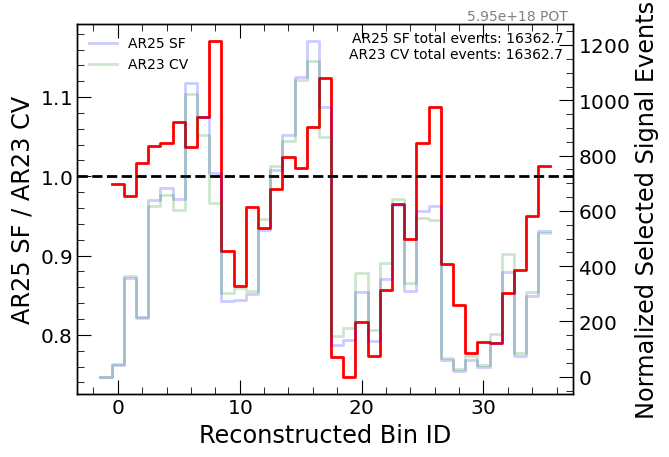

In [164]:
from sbnd.plotlibrary import makeplot
fig,ax = plt.subplots()
ax2 = ax.twinx()
makeplot.plot_hist_edges(edges,vals_sf/vals_cv,label='ratio',color='red',ax=ax)
makeplot.plot_hist_edges(edges,vals_sf,label='AR25 SF',color='blue',ax=ax2,alpha=0.2)
makeplot.plot_hist_edges(edges,vals_cv,label='AR23 CV',color='green',ax=ax2,alpha=0.2)
ax2.legend(loc='upper left')

ax.axhline(1,color='black',linestyle='--')
ax.set_xlabel('Reconstructed Bin ID')
ax.set_ylabel('AR25 SF / AR23 CV')
ax2.set_ylabel('Normalized Selected Signal Events')
label = f'AR25 SF total events: {vals_sf.sum():.1f}'\
  + f'\nAR23 CV total events: {vals_cv.sum():.1f}'
plotters.add_label(ax,label,where='topright',color='black',alpha=1.,fontsize=10)
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray',alpha=1.,fontsize=10)

## Testing

In [127]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/full/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_sigma_tilde.csv'
bear_arr = np.loadtxt(fname).T

fname_cv = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/full/metadata/differential_sigma_tilde.csv'
bear_arr_cv = np.loadtxt(fname_cv).T

fname_cov = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/full/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_xsec_fraccov.csv'
bear_cov = np.loadtxt(fname_cov)

fname_fracunc = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/full/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_xsec_fracunc.csv'
bear_fracunc = np.loadtxt(fname_fracunc)

xsec_unit = 2.171289064868864083e-43

In [137]:
np.diag(np.sqrt(bear_cov)) - bear_fracunc


/tmp/ipykernel_100161/3214714780.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.diag(np.sqrt(bear_cov)) - bear_fracunc


array([ 0.00000000e+00,  0.00000000e+00,  1.73472348e-18, -3.46944695e-18,
        3.46944695e-18, -1.73472348e-18,  0.00000000e+00, -8.67361738e-19,
        0.00000000e+00,  6.93889390e-18,  0.00000000e+00,  3.46944695e-18,
        3.46944695e-18,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -1.73472348e-18, -4.33680869e-19, -3.46944695e-18,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.73472348e-18,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.93889390e-18, -1.73472348e-18,  1.73472348e-18,  3.46944695e-18,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -6.93889390e-18,
       -3.46944695e-18])

In [134]:
np.diag(np.sqrt(bear_cov))

/tmp/ipykernel_100161/815188758.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.diag(np.sqrt(bear_cov))


array([0.        , 0.01938412, 0.01376492, 0.01573944, 0.01245771,
       0.00968332, 0.01478538, 0.00399412, 0.01323311, 0.05178131,
       0.00356276, 0.02862574, 0.01315161, 0.01219855, 0.01370712,
       0.01051323, 0.00834345, 0.01089214, 0.00311728, 0.01950837,
       0.04981522, 0.0371933 , 0.04673706, 0.03083776, 0.0094983 ,
       0.04024363, 0.01104041, 0.00727521, 0.03946247, 0.01435323,
       0.0153356 , 0.02840767, 0.05563534, 0.05730212, 0.0644483 ,
       0.04030392, 0.02057771])

/tmp/ipykernel_100161/3602291863.py:2: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x,np.diag(np.sqrt(bear_cov)),label='cov')


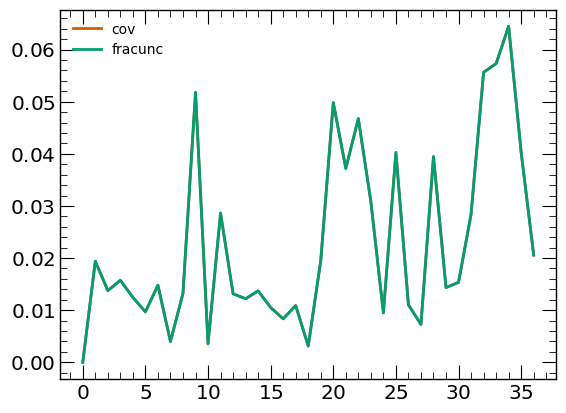

In [136]:
x = np.arange(len(bear_cov))
plt.plot(x,np.diag(np.sqrt(bear_cov)),label='cov')
plt.plot(x,bear_fracunc,label='fracunc')
#plt.plot(x,np.diag(np.sqrt(bear_cov))/bear_fracunc,label='fracunc/cov')
plt.legend()
plt.show()


In [123]:
ind = 20
frac_uncs = (bear_arr[ind] - bear_arr_cv[ind])/bear_arr_cv[ind]
frac_uncs

array([-0.02888814,  0.02296644, -0.05801603,  0.04318553, -0.0670276 ,
        0.06167498])

In [124]:
np.mean(np.abs(frac_uncs))

0.04695978674182683

In [146]:
 systematics = r23p_genie_systematics + qe_genie_systematics + mec_genie_systematics + res_genie_systematics + nonres_genie_systematics + dis_genie_systematics + other_genie_systematics

In [147]:
len(systematics)

84

[autoreload of sbnd.stats.systematics failed: Traceback (most recent call last):
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/IPython/extensions/au

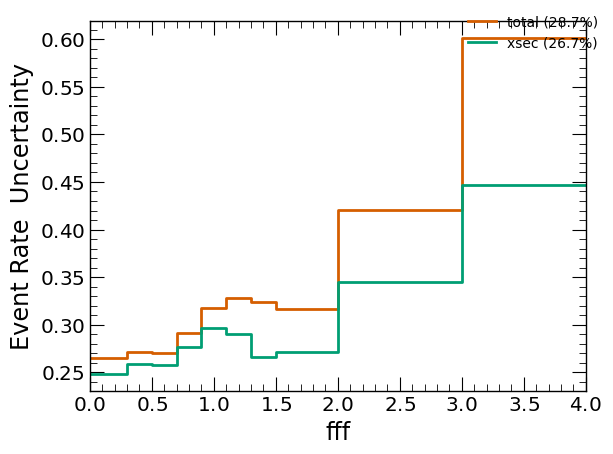

In [109]:
msystematics.xlabel = 'fff'
fig,ax,_ = msystematics.plot_event_rate_errs('event',sort=True,include_keys=['total','xsec'])

In [104]:
ax.legend(ncol=1,loc='upper right',bbox_to_anchor=(1.05, 1.05))
plt.show()

In [193]:
FNAME = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/mc_smallpand_fullsyst_cut_norecomb.df'
key = 'evt_pand_signal_0'
slc = CAFSlice.load(FNAME,key=key)

In [189]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_truth_negativecnt.txt','w') as f:
  for col in slc.data.truth.keys():
    ssum = (slc.data.truth.loc[:,col] < 0).sum()
    string = f'{col}: {ssum}\n'
    if ssum > 0:
      f.write(string)

In [194]:
slc.data.truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms3.idxmin()

(85, 166, 1)

In [196]:
ind = (85,166,1)
keys = ['run','subrun','evt',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps3',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps2',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ps1',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms3',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms2',
  'truth.CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4.ms1',
  ]
cols = slc.get_key(keys)
slc.data.loc[ind,cols]

run                                                                             2783.0
subrun                                                                             4.0
evt                                                                               29.0
truth   CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4  ps3                 100.0
                                                             ps2                 100.0
                                                             ps1                 100.0
                                                             ms3                  -inf
                                                             ms2                  -inf
                                                             ms1                  -inf
Name: (85, 166, 1), dtype: float64

In [81]:
slc.data.keys()

Index(['pot', 'first_in_subrun', 'ismc', 'run', 'subrun', 'ngenevt', 'evt',
       'proc', 'cluster', 'fno', 'noffbeambnb'],
      dtype='object')

In [66]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_weights2.txt','w') as f:
  for k in df.keys():
    f.write(f'{k}\n')


In [190]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_singlepand_slimsyst_nocuts_norecomb2.df'
h5 = h5py.File(fname,'r')
h5.keys()

<KeysViewHDF5 ['evt_pand_0', 'hdr_0', 'histgenevtdf_0', 'histpotdf_0', 'mcnu_0', 'split']>

In [ ]:
df = pd.read_hdf(fname,key='evt_pand_0')

In [ ]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_slimsyst_keys.txt','w') as f:
  for k in df.truth.keys():
    f.write(f'{k}\n')

In [63]:
import uproot
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/single.root'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tmp/temp0_ec6a979a-7730-4e0d-bcb2-82fbbb5ac2ae.flat.caf.root'
#fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbn/data_add/sbn_nd/poms_production/mc/MCP2025B_v10_06_00_09/v10_06_00_09/prodgenie_corsika_proton_rockbox_sbnd/CV/caf/00/00/caf-340768b0-4bb8-4575-8a9a-c64e68efc880.root'
fname = '/exp/sbnd/app/users/gputnam/Ar23-knobs/test.root'
tree = uproot.open(fname)['recTree']#['rec/slc']
tree.keys()
[k for k in tree.keys() if 'barycenterFM' in k]

['rec.slc.barycenterFM.chargeCenter.x',
 'rec.slc.barycenterFM.chargeCenter.y',
 'rec.slc.barycenterFM.chargeCenter.z',
 'rec.slc.barycenterFM.chargeCenterXLocal',
 'rec.slc.barycenterFM.chargeTotal',
 'rec.slc.barycenterFM.chargeWidth.x',
 'rec.slc.barycenterFM.chargeWidth.y',
 'rec.slc.barycenterFM.chargeWidth.z',
 'rec.slc.barycenterFM.chi2',
 'rec.slc.barycenterFM.deltaT',
 'rec.slc.barycenterFM.deltaY',
 'rec.slc.barycenterFM.deltaY_Trigger',
 'rec.slc.barycenterFM.deltaZ',
 'rec.slc.barycenterFM.deltaZ_Trigger',
 'rec.slc.barycenterFM.flashAsymmetry',
 'rec.slc.barycenterFM.flashCenter.x',
 'rec.slc.barycenterFM.flashCenter.y',
 'rec.slc.barycenterFM.flashCenter.z',
 'rec.slc.barycenterFM.flashFirstHit',
 'rec.slc.barycenterFM.flashPEs',
 'rec.slc.barycenterFM.flashTime',
 'rec.slc.barycenterFM.flashWidth.x',
 'rec.slc.barycenterFM.flashWidth.y',
 'rec.slc.barycenterFM.flashWidth.z',
 'rec.slc.barycenterFM.overlapY',
 'rec.slc.barycenterFM.overlapZ',
 'rec.slc.barycenterFM.radius

In [58]:
tree['globalTree/global/wgts/wgts.name'].arrays(library='np')

{'wgts.name': array([array(['GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE',
               'GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE',
               'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
               'GENIEReWeight_SBN_v1_multisigma_RPA_CCQE',
               'GENIEReWeight_SBN_v1_multisigma_CoulombCCQE',
               'GENIEReWeight_SBN_v1_multisigma_NormCCMEC',
               'GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
               'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
               'GENIEReWeight_SBN_v1_multisigma_MaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_EtaNCEL',
               'GENIEReWeight_SBN_v1_multisigma_MaCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MaNCRES',
               'GENIEReWeight_SBN_v1_multisigma_MvNCRES',
               'GENIEReWeigh

In [522]:
import uproot
bugfix_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000_liang_bugfix/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(bugfix_fname)
df_bf = tree['FlatTree_VARS'].arrays(library='pd')

nominal_fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/persistent/users/apapadop/GENIETweakedSamples/v3_6_2_AR23_20i_00_000/14_1000180400_CC_v3_6_2_AR23_20i_00_000.flat.root'
tree = uproot.open(nominal_fname)
df_nom = tree['FlatTree_VARS'].arrays(library='pd')

In [536]:
df_nom.keys()

Index(['Mode', 'GENIEResCode', 'cc', 'PDGnu', 'Enu_true', 'tgt', 'tgta',
       'tgtz', 'PDGLep', 'ELep', 'CosLep', 'Q2', 'q0', 'q3', 'Enu_QE', 'Q2_QE',
       'W_nuc_rest', 'W', 'W_genie', 'x', 'y', 'Erecoil_minerva',
       'Erecoil_charged', 'EavAlt', 'Emiss', 'pmiss', 'Emiss_preFSI',
       'pmiss_preFSI', 'CosThetaAdler', 'PhiAdler', 'dalphat', 'dpt', 'dphit',
       'pnreco_C', 'nfsp', 'px', 'py', 'pz', 'E', 'pdg', 'pdg_rank', 'ninitp',
       'px_init', 'py_init', 'pz_init', 'E_init', 'pdg_init', 'nvertp',
       'px_vert', 'py_vert', 'pz_vert', 'E_vert', 'pdg_vert', 'Weight',
       'InputWeight', 'RWWeight', 'fScaleFactor', 'CustomWeight',
       'CustomWeightArray', 'flagCCINC', 'flagNCINC', 'flagCCQE', 'flagCC0pi',
       'flagCCQELike', 'flagNCEL', 'flagNC0pi', 'flagCCcoh', 'flagNCcoh',
       'flagCC1pip', 'flagNC1pip', 'flagCC1pim', 'flagNC1pim', 'flagCC1pi0',
       'flagNC1pi0', 'flagCC0piMINERvA', 'flagCC0Pi_T2K_AnaI',
       'flagCC0Pi_T2K_AnaII'],
      dtype='object

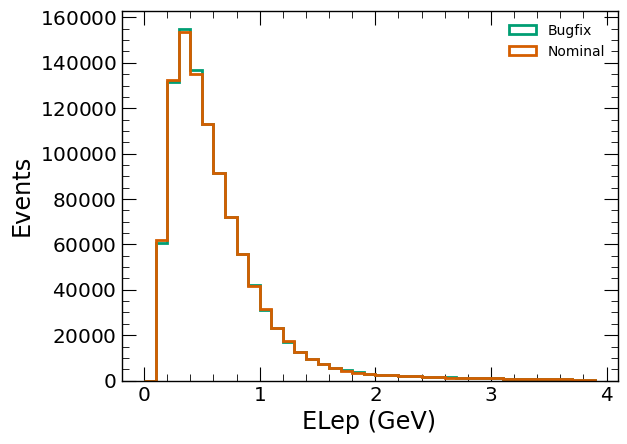

In [ ]:
#np.arange(0,4,.1)
plt.hist([df_nom['ELep'],df_bf['ELep']],bins=np.arange(0,4,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel('ELep (GeV)');
plt.ylabel('Events');

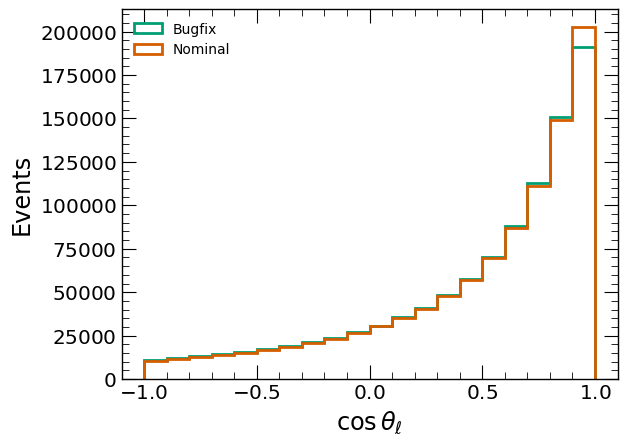

In [541]:
plt.hist([df_nom['CosLep'],df_bf['CosLep']],bins=np.arange(-1,1.1,.1),label=['Nominal','Bugfix'],histtype='step');
plt.legend();
plt.xlabel(r'$\cos\theta_\ell$');
plt.ylabel('Events');

In [812]:
from analysis_village.unfolding.wienersvd import WienerSVD

print("=== Test 1: Perfect Case ===")
n_bins = 5
identity_response = np.eye(n_bins)
identity_response[1,0] = 0.1
test_signal = np.array([100.0, 100.0, 100.0, 100.0, 100.0])
test_measured = test_signal.copy()  # Same as signal
test_measured[1] = 1000.0
test_cov = np.diag(test_signal)*100  # Identity covariance

result1 = WienerSVD(identity_response, test_signal, test_measured, test_cov, 0, 0.0)
print(f"Unfolded result: {result1['unfold']}")
print(f"Should equal signal: {np.allclose(result1['unfold'], test_signal)}")
print(f"AddSmear should be identity: {np.allclose(result1['AddSmear'], np.eye(n_bins))}")
print("AddSmear matrix:")
print(result1['AddSmear'])
print(f"AddSmear diagonal: {np.diag(result1['AddSmear'])}")
print(f"AddSmear column sums: {np.sum(result1['AddSmear'], axis=0)}")

=== Test 1: Perfect Case ===
-Response: [[1.  0.  0.  0.  0. ]
 [0.1 1.  0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]
-Signal: [100. 100. 100. 100. 100.]
-Measure: [ 100. 1000.  100.  100.  100.]
-Covariance: [[10000.     0.     0.     0.     0.]
 [    0. 10000.     0.     0.     0.]
 [    0.     0. 10000.     0.     0.]
 [    0.     0.     0. 10000.     0.]
 [    0.     0.     0.     0. 10000.]]
-C_type: 0
-Norm_type: 0.0
-U_cov: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-s_cov: [10000. 10000. 10000. 10000. 10000.]
-Q0: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-Q: [[0.01 0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.  ]
 [0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.01]]
-M_trans: [ 1. 10.  1.  1.  1.]
-R: [[0.01  0.    0.    0.    0.   ]
 [0.001 0.01  0.    0.    0.   ]
 [0.    0.    0.01  0.    0.   ]
 [0.    0.    0

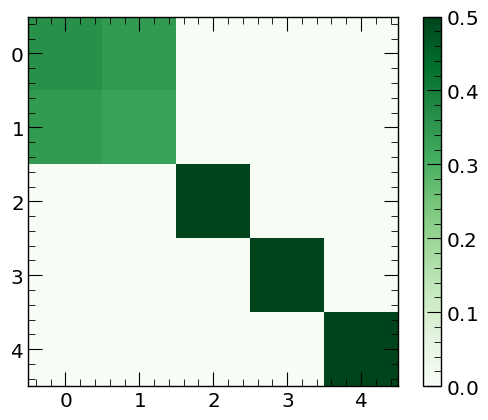

In [813]:
plt.imshow(result1['AddSmear'])
plt.colorbar()

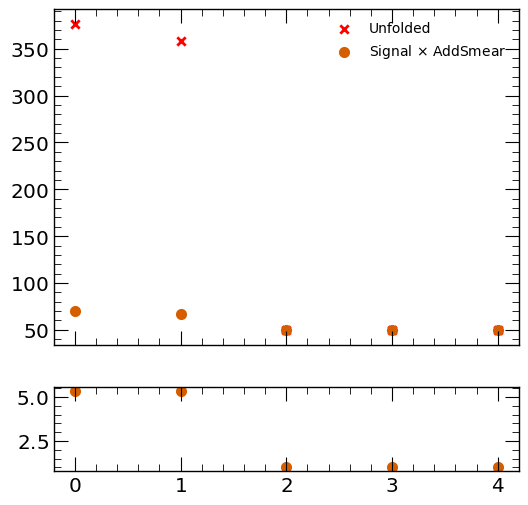

In [814]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,6),sharex=True,height_ratios=[4,1])
ax1.scatter(np.arange(n_bins),result1['unfold'],marker='x',color='red',label='Unfolded')
ax1.scatter(np.arange(n_bins),test_signal@result1['AddSmear'],label=r'Signal $\times$ AddSmear')
ax2.scatter(np.arange(n_bins),result1['unfold']/(test_signal@result1['AddSmear']))
ax1.legend()


In [808]:
_inter = inter.copy()

In [282]:
flux_keys = list(set([k[1] for k in _inter.data.keys() if 'Flux' in k[1]]))
with open('flux_keys.txt','w') as f:
  f.write(str(flux_keys))
flux_keys


['pionqexsec_Flux',
 'kplus_Flux',
 'pioninexsec_Flux',
 'nucleontotxsec_Flux',
 'nucleoninexsec_Flux',
 'horncurrent_Flux',
 'piplus_Flux',
 'piontotxsec_Flux',
 'kminus_Flux',
 'expskin_Flux',
 'nucleonqexsec_Flux',
 'Flux',
 'piminus_Flux',
 'kzero_Flux']

In [271]:
genie_keys = list(set([k[1] for k in slc.data.keys() if 'GENIE' in k[1]]))
genie_keys

['GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1eta',
 'GENIE',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC2pi',
 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NormCCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1gamma',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC2pi',
 'GENIEReWeight_SBN_v

In [83]:
_inter.add_stat_unc()

Generating event seeds: 100%|██████████| 309285/309285 [00:02<00:00, 110934.58it/s]


Successfully generated 309285 unique seeds


Generating universes: 100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


In [86]:
_inter.data.truth.stat.univ_0.value_counts(normalize=True)

univ_0
1.0    0.367936
0.0    0.367386
2.0    0.184655
3.0    0.061238
4.0    0.015167
5.0    0.002971
6.0    0.000566
7.0    0.000061
8.0    0.000019
Name: proportion, dtype: float64

In [160]:
fname = f'{os.path.join(DATA_DIR,"small/mc_small_syst_postprocess_cut.df")}'
#df = pd.read_hdf(fname,key='evt_0')

In [38]:
list(df.keys())

[('id', '', '', '', '', ''),
 ('is_cathode_crosser_x', '', '', '', '', ''),
 ('is_contained_x', '', '', '', '', ''),
 ('is_fiducial_x', '', '', '', '', ''),
 ('is_flash_matched', '', '', '', '', ''),
 ('is_truth', '', '', '', '', ''),
 ('num_particles_x', '', '', '', '', ''),
 ('num_primary_particles_x', '', '', '', '', ''),
 ('vertex', 'x', '', '', '', ''),
 ('vertex', 'y', '', '', '', ''),
 ('vertex', 'z', '', '', '', ''),
 ('flash_hypo_pe', '', '', '', '', ''),
 ('flash_total_pe', '', '', '', '', ''),
 ('match_overlaps', '', '', '', '', ''),
 ('current_type', '', '', '', '', ''),
 ('energy_init', '', '', '', '', ''),
 ('energy_transfer', '', '', '', '', ''),
 ('num_particles_y', '', '', '', '', ''),
 ('num_primary_particles_y', '', '', '', '', ''),
 ('inelasticity', '', '', '', '', ''),
 ('interaction_mode', '', '', '', '', ''),
 ('interaction_type', '', '', '', '', ''),
 ('is_cathode_crosser_y', '', '', '', '', ''),
 ('is_contained_y', '', '', '', '', ''),
 ('is_fiducial_y', '', ''

In [161]:
with h5py.File(fname, 'r') as f:
    keys = list(f.keys())  # Convert the KeysViewWithLock object to a list for easier viewing
    print(keys)

['mcnu', 'pandora', 'pandora_signal', 'spine', 'spine_signal']
